# 电商销售数据分析

**数据来源**：UCI Machine Learning Repository · Online Retail 数据集
（英国某线上零售商 2010-12 ~ 2011-12 的真实交易明细）

**分析目标**：在真实电商交易数据上完成从数据质量体检、销售分析、客户价值分层（RFM）、
购物篮关联规则到销售预测的完整链路。

**使用说明**：本 notebook 默认加载随仓库提交的抽样样本（3.2 万行），保证可一键复现；
设置环境变量 `USE_FULL_DATA=1` 可切换到完整 45 万行数据。

---

## 0. 环境准备

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# 让 notebook 能 import 到 src 包
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import analysis, data_loader, market_basket, modeling, visualize
from src.config import apply_style

apply_style()
pd.set_option("display.unicode.east_asian_width", True)
pd.set_option("display.max_columns", 50)

from IPython.display import Image, display


def show(path):
    # 重新加载 PNG 显示（绘图函数内部会关闭 figure，因此不能依赖 inline 输出）
    display(Image(filename=str(path)))


print("工作目录:", ROOT)

工作目录: C:\Users\Administrator\WorkBuddy\2026-10-08-07-53-07\ecommerce-sales-analysis


---

## 1. 数据加载与质量体检

第一步不是算指标，而是**搞清楚这份数据能回答什么问题**。

In [2]:
raw = data_loader.load_raw()
print(f"原始数据：{raw.shape[0]:,} 行 × {raw.shape[1]} 列")
raw.head()

原始数据：32,003 行 × 8 列


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536399,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 10:52:00,1.85,17850.0,United Kingdom
1,536399,22633,HAND WARMER UNION JACK,6,2010-12-01 10:52:00,1.85,17850.0,United Kingdom
2,536400,22969,HOMEMADE JAM SCENTED CANDLES,12,2010-12-01 10:53:00,1.45,13448.0,United Kingdom
3,536437,21154,RED RETROSPOT OVEN GLOVE,200,2010-12-01 12:12:00,1.06,13694.0,United Kingdom
4,536437,22189,CREAM HEART CARD HOLDER,72,2010-12-01 12:12:00,3.39,13694.0,United Kingdom


In [3]:
quality = data_loader.quality_report(raw)
quality

,指标,数值
0,总行数,"32,003"
1,唯一发票数,"1,500"
2,唯一客户数,932
3,唯一商品数,"3,141"
4,时间范围,2010-12-01 10:52:00 ~ 2011-12-09 11:57:00
5,覆盖国家数,24
6,CustomerID 缺失,"8,482 (26.5%)"
7,Description 缺失,99 (0.3%)
8,重复行,338
9,负数量（退货）,600 (1.87%)


### 1.1 关键数据质量问题

- **CustomerID 缺失约 26%**：多为无账户的散客或退货记录，无法做客户级分析
- **负数量（退货）约 1.9%**：发票号以 C 开头的是取消订单
- **单价 ≤ 0 约 0.5%**：多为赠品/坏损调整，不应计入销售
- **重复行**：同一发票完全相同的行需要去重

> 分析口径：清洗时剔除无客户ID记录与退货/异常单价，
> 得到「正常销售交易」用于客户分析与购物篮分析。

In [4]:
df = data_loader.load_clean()
print(f"清洗后：{df.shape[0]:,} 行，{df['InvoiceNo'].nunique():,} 张发票，"
      f"{df['CustomerID'].nunique():,} 个客户")
print(f"总销售额：£{(df['Quantity'] * df['UnitPrice']).sum():,.0f}")

清洗后：22,679 行，1,049 张发票，813 个客户
总销售额：£526,478


---

## 2. 销售趋势分析

### 2.1 月度趋势

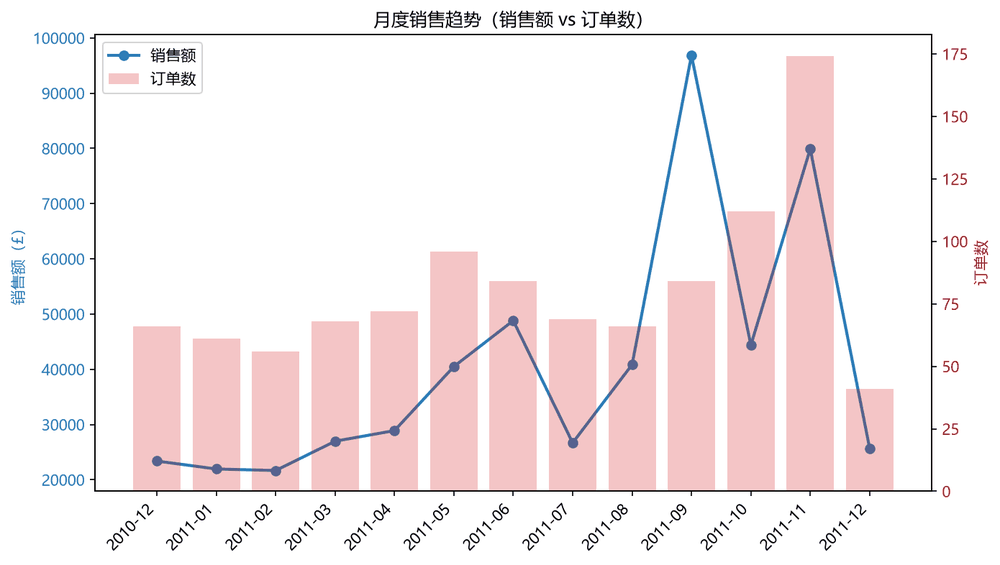

,year_month,订单数,销售额,客户数,平均客单价
0,2010-12,66,23381.960,58,17.740486
1,2011-01,61,21942.330,58,14.795907
2,2011-02,56,21665.270,54,20.342977
3,2011-03,68,26972.050,66,19.007787
4,2011-04,72,28892.801,72,16.510172
5,2011-05,96,40494.250,92,27.509681
6,2011-06,84,48809.010,79,32.047938
7,2011-07,69,26677.480,68,18.526028
8,2011-08,66,40833.360,64,31.194316
9,2011-09,84,96835.870,81,47.820183


In [5]:
monthly = analysis.monthly_trend(df)
show(visualize.plot_monthly_trend(monthly))
monthly

**观察**：9-11 月是明显的销售旺季（圣诞备货），9 月出现峰值；
2011-12 只有 9 天数据，不代表当月真实水平。

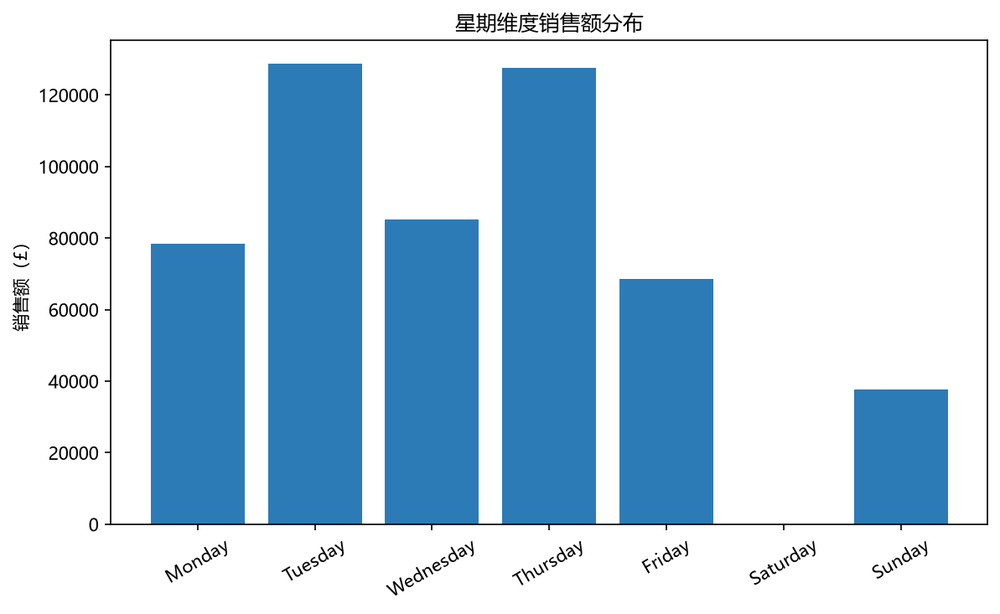

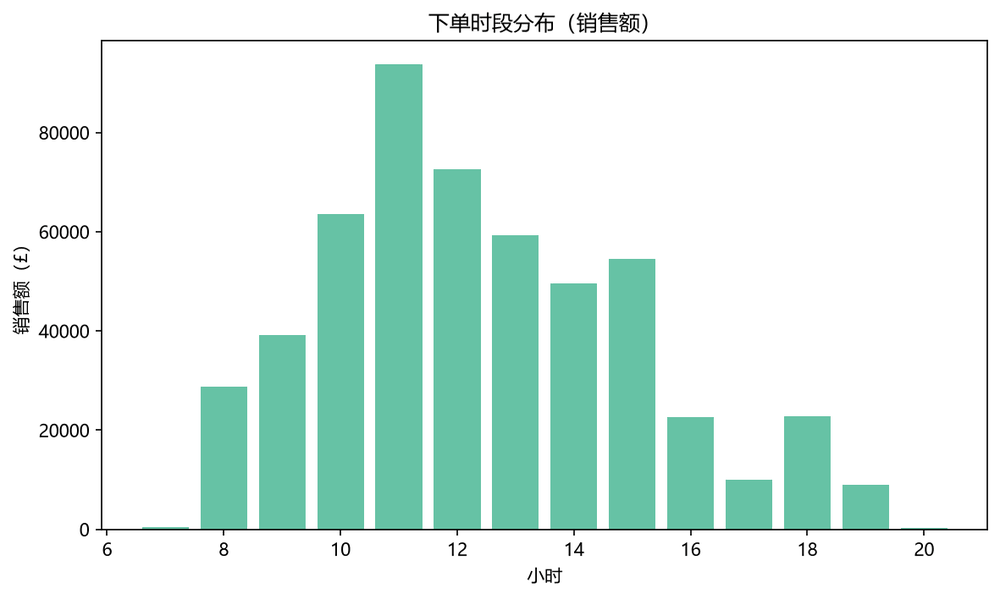

,weekday_name,订单数,销售额,销售额占比
0,Monday,150.0,78396.790,0.148908
1,Tuesday,180.0,128789.090,0.244624
2,Wednesday,204.0,85238.500,0.161903
3,Thursday,228.0,127622.030,0.242407
4,Friday,169.0,68645.821,0.130387
5,Saturday,NaN,NaN,NaN
6,Sunday,118.0,37785.470,0.071770


In [6]:
weekday = analysis.weekday_distribution(df)
hour = analysis.hour_distribution(df)
show(visualize.plot_weekday(weekday))
show(visualize.plot_hour(hour))
weekday

**观察**：周中（周二至周四）是下单高峰，**周六无交易**（该零售商周六不营业）；
时段集中在 10:00-15:00，与英国办公时间一致，说明客户以批发商/企业采购为主。

---

## 3. 商品与国家结构

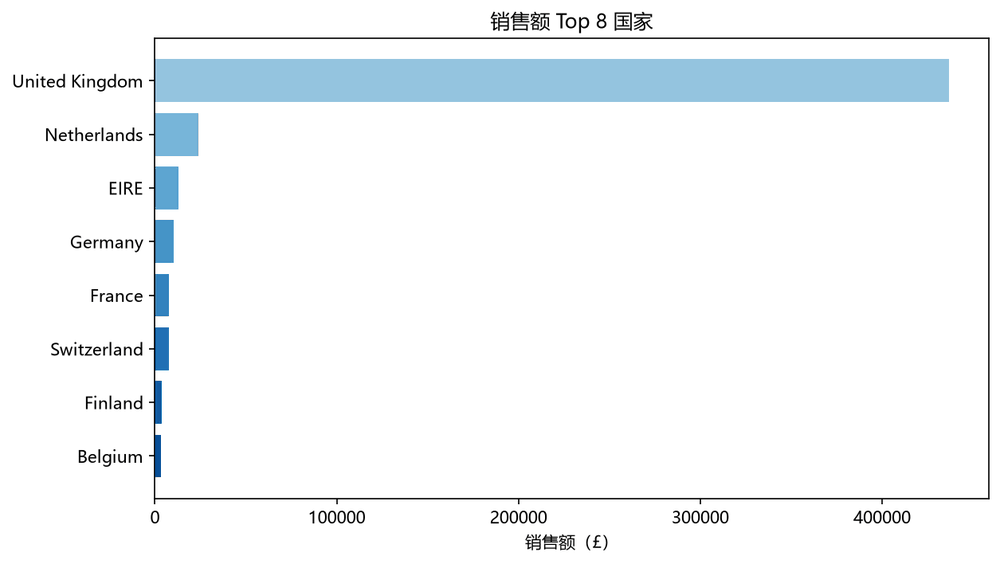

,Country,订单数,销售额,客户数,件数,销售额占比,客单价
22,United Kingdom,947,436736.521,732,258400,0.829544,461.179008
14,Netherlands,5,24139.060,1,17813,0.045850,4827.812000
5,EIRE,9,12991.140,2,7883,0.024676,1443.460000
9,Germany,21,10417.550,20,6361,0.019787,496.073810
8,France,19,7765.150,16,4025,0.014749,408.692105
21,Switzerland,3,7569.400,3,3898,0.014377,2523.133333
7,Finland,4,3855.790,3,1379,0.007324,963.947500
1,Belgium,8,3438.430,8,1783,0.006531,429.803750
0,Austria,3,3206.660,3,1627,0.006091,1068.886667
3,Channel Islands,2,2540.620,2,1273,0.004826,1270.310000


In [7]:
country = analysis.country_breakdown(df)
show(visualize.plot_country(country))
country.head(10)

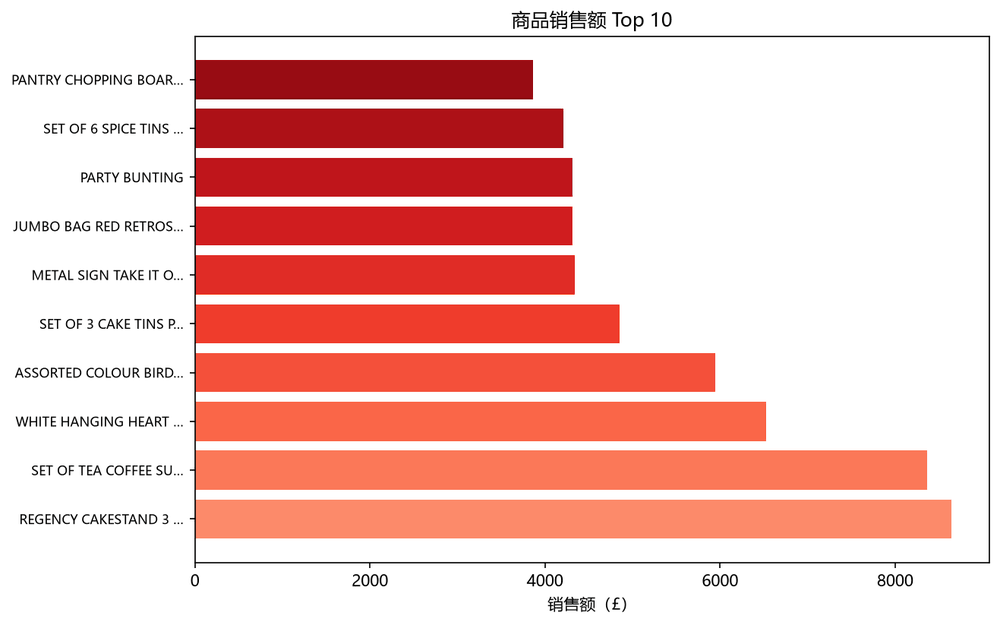

,StockCode,Description,销售额,件数,订单数
1094,22423,REGENCY CAKESTAND 3 TIER,8643.76,749,110
1866,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,8362.66,1730,26
2684,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6529.86,2290,113
2550,84879,ASSORTED COLOUR BIRD ORNAMENT,5947.12,3928,75
1370,22720,SET OF 3 CAKE TINS PANTRY DESIGN,4856.37,983,65
1084,22413,METAL SIGN TAKE IT OR LEAVE IT,4344.75,1581,26
2674,85099B,JUMBO BAG RED RETROSPOT,4318.76,2280,90
2278,47566,PARTY BUNTING,4313.27,953,84
1372,22722,SET OF 6 SPICE TINS PANTRY DESIGN,4209.25,1007,33
1732,23113,PANTRY CHOPPING BOARD,3860.01,763,4


In [8]:
product = analysis.product_breakdown(df, top_n=10)
show(visualize.plot_product(product))
product

**观察**：英国本土占绝对主导（样本中约 80%+），其他市场以欧洲为主；
商品结构高度分散，头部商品多为装饰类、礼品类小商品，客单价低但复购率高。

---

## 4. RFM 客户价值分层

RFM 是最经典的客户价值模型：

- **R（Recency）**：最近一次购买距今天数（越小越好）
- **F（Frequency）**：购买次数
- **M（Monetary）**：累计消费金额

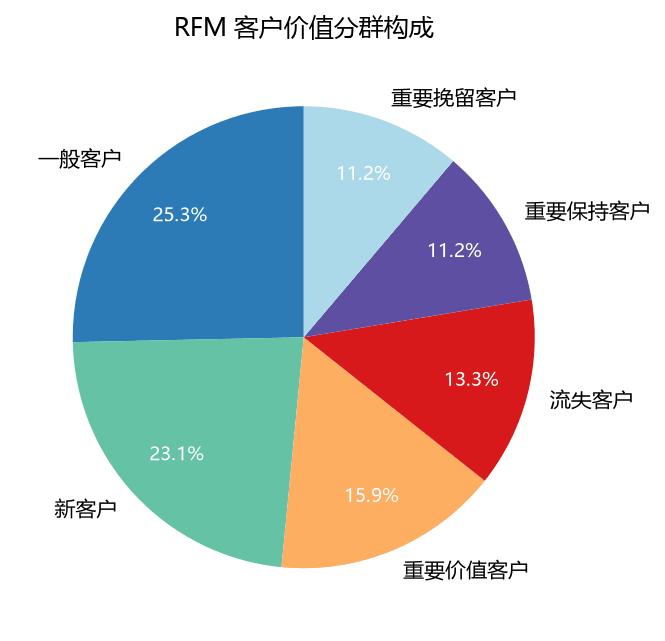

,客户分群,客户数,平均消费,总消费,平均频次
3,重要价值客户,129,1870.779767,241330.590,2.224806
1,新客户,188,454.017234,85355.240,1.000000
5,重要挽留客户,91,807.933846,73521.980,1.637363
0,一般客户,206,265.287864,54649.300,1.053398
2,流失客户,108,505.858991,54632.771,1.000000
4,重要保持客户,91,186.679341,16987.820,1.098901


In [9]:
rfm = analysis.rfm_segmentation(df)
summary = analysis.rfm_summary(rfm)
show(visualize.plot_rfm(rfm))
summary

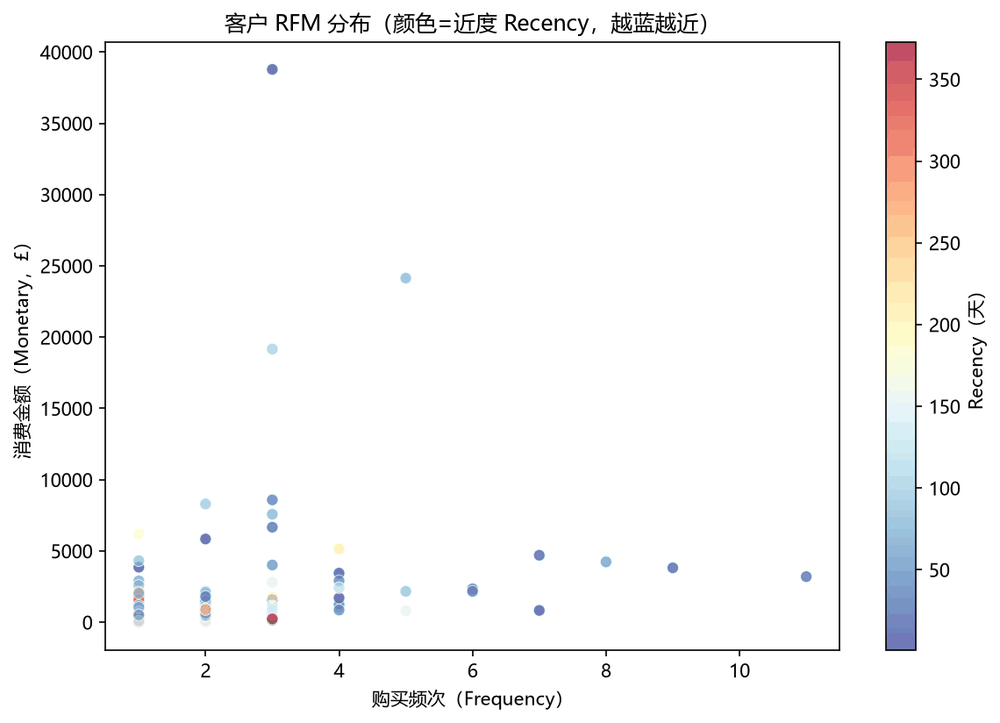

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,客户分群
696,17450,8,3,38779.24,4,4,4,444,重要价值客户
305,14646,81,5,24139.06,3,4,4,344,重要价值客户
85,12931,101,3,19160.68,3,4,4,344,重要价值客户
684,17389,36,3,8580.52,4,4,4,444,重要价值客户
239,14156,95,2,8293.86,3,4,4,344,重要价值客户
785,18102,78,3,7573.56,3,4,4,344,重要价值客户
188,13777,24,3,6664.60,4,4,4,444,重要价值客户
13,12409,182,1,6207.08,2,1,4,214,流失客户
579,16684,4,2,5838.84,4,4,4,444,重要价值客户
365,15061,211,4,5144.86,2,4,4,244,重要挽留客户


In [10]:
show(visualize.plot_rfm_scatter(rfm))
analysis.top_customers(rfm, 10)

**观察与策略**：

- **重要价值客户（R高F高M高）**：核心客群，优先维护，VIP 服务
- **重要挽留客户（F/M高但R低）**：有流失风险的高价值客户，需定向召回
- **新客户**：首购转化，重点培养复购习惯
- **流失客户**：低成本召回或放弃，控制营销预算

---

## 5. 购物篮关联分析

基于 Apriori 算法挖掘「买 A 的顾客也倾向买 B」：

- **支持度（Support）**：同时包含 A、B 的订单占比
- **置信度（Confidence）**：买 A 的人中有多少也买 B
- **提升度（Lift）**：A 对 B 的拉动倍数，>1 为正相关，越大越强

In [11]:
basket = market_basket.build_basket(df)
print(f"购物篮数：{len(basket):,}，商品数：{basket.shape[1]:,}")
frequent = market_basket.frequent_itemsets(basket, min_support=0.02)
rules = market_basket.get_rules(frequent, metric="lift", min_threshold=1.0)
print(f"频繁项集：{len(frequent)}，关联规则：{len(rules)}")

购物篮数：965，商品数：2,847
频繁项集：322，关联规则：148


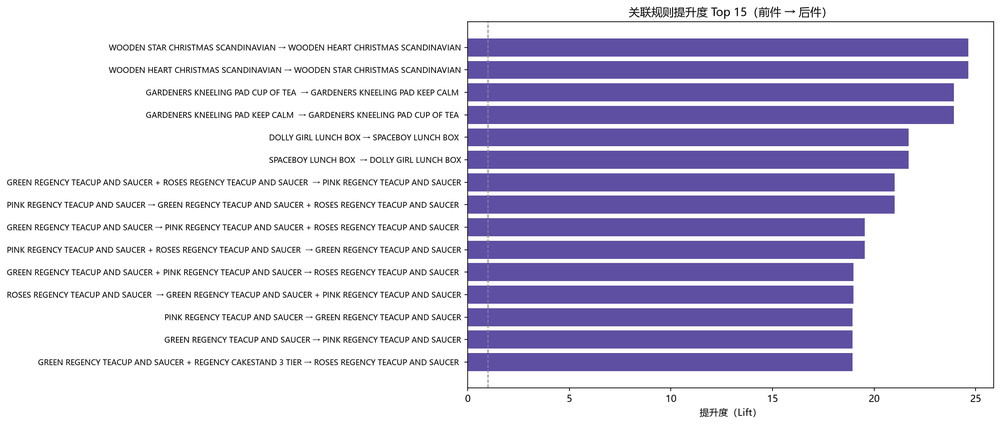

,前件,后件,支持度,置信度,提升度
0,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.020725,0.689655,24.648787
1,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.020725,0.740741,24.648787
2,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.025907,0.892857,23.933532
3,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.025907,0.694444,23.933532
4,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.023834,0.696970,21.695992
5,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.023834,0.741935,21.695992
6,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,PINK REGENCY TEACUP AND SAUCER,0.027979,0.675000,21.012097
7,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,0.027979,0.870968,21.012097
8,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,0.027979,0.586957,19.531484
9,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,GREEN REGENCY TEACUP AND SAUCER,0.027979,0.931034,19.531484


In [12]:
top_rules = market_basket.top_rules(rules, n=15)
show(visualize.plot_rules(top_rules))
top_rules

**观察**：最强关联集中在「同系列不同款式」——圣诞木星星/心形、
园艺跪垫、午餐盒、Regency 茶具系列。这些是**天然的捆绑销售与推荐组合**：
顾客买了一件还会买同系列其他款式做搭配。

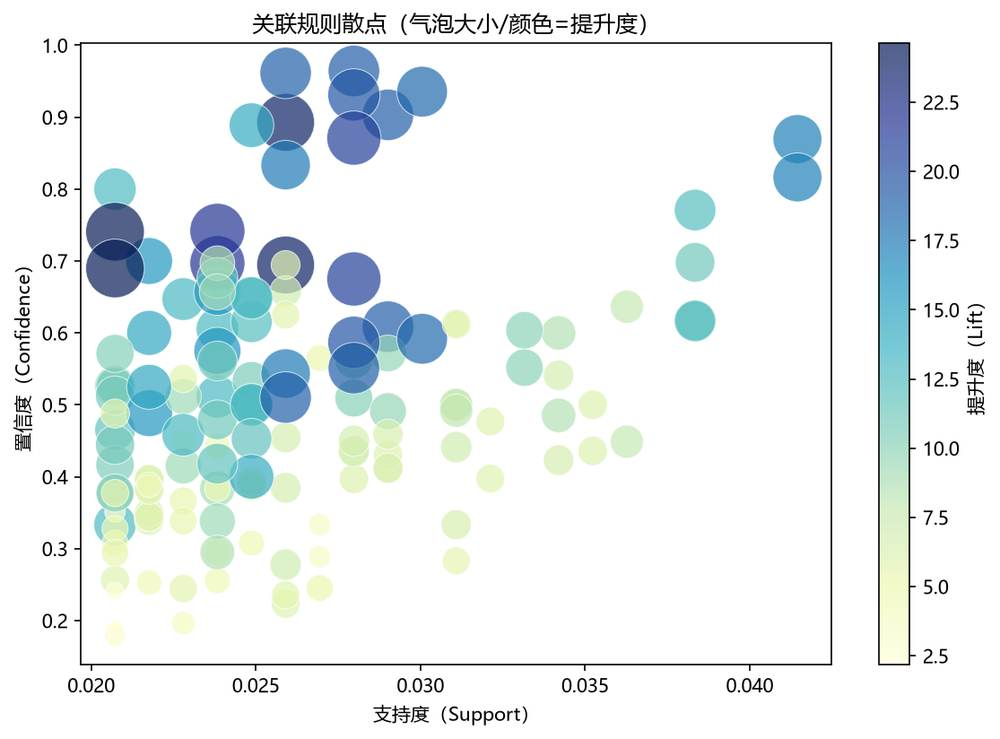

In [13]:
show(visualize.plot_rules_scatter(rules))

---

## 6. 销售预测

对月度销售额做时间序列预测。样本只有 13 个月，季节项统计意义不足，
因此使用 **Holt 线性趋势平滑**，并与朴素法、移动平均做回测对比。

In [14]:
series = modeling.build_monthly_series(df)
model_comparison = modeling.evaluate_models(series, test_size=3)
model_comparison

,模型,MAE,RMSE,MAPE
0,朴素法,46844.763333,51962.384348,138.767839
1,移动平均(3),21541.952222,22991.573719,56.038866
2,Holt-Winters,39551.109413,47600.423779,126.343044


**观察**：移动平均表现最优（MAPE 56%），Holt 次之。这说明序列噪声大、
趋势不显著——**短序列上简单模型反而更稳**，强行上复杂模型容易过拟合。

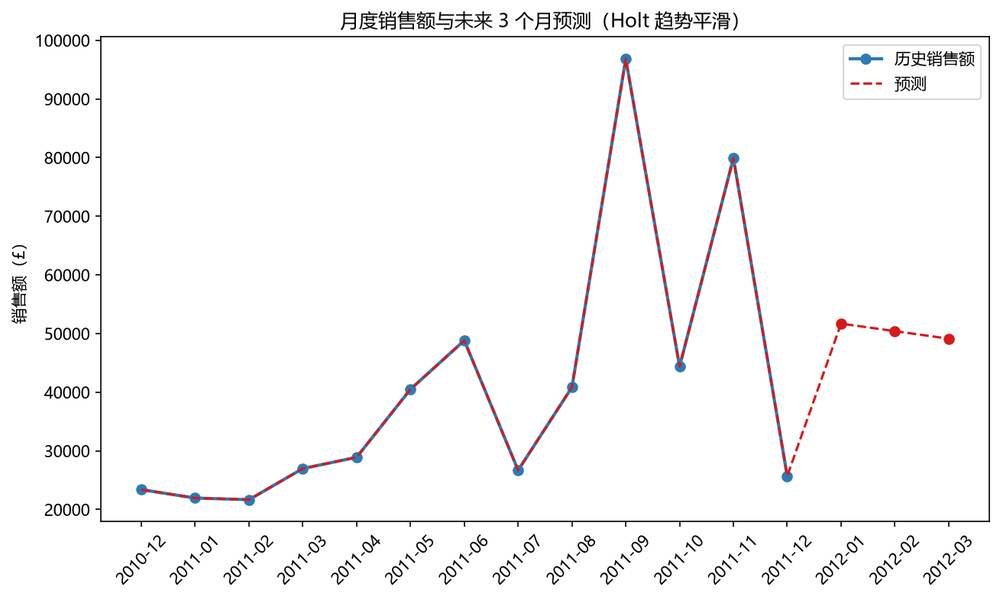

,月份,预测销售额
0,2012-01,51687.918661
1,2012-02,50402.805150
2,2012-03,49117.691638


In [15]:
forecast = modeling.forecast_next(series, horizon=3)
show(visualize.plot_forecast(series, forecast))
forecast

---

## 7. 小结

| 分析方向 | 核心结论 |
| :--- | :--- |
| 数据质量 | CustomerID 缺失 26%、退货 1.9%、异常单价 0.5%，清洗后 22,679 行有效交易 |
| 时间趋势 | 9-11 月圣诞备货旺季；周中高峰、周六不营业；下单集中在 10-15 点 |
| 商品结构 | 英国主导、欧洲市场为主；头部商品为礼品/装饰类小商品 |
| RFM 分层 | 129 个重要价值客户贡献 £241k（占 46%），是核心维护对象 |
| 购物篮 | 同系列商品强关联（Lift 20+），是天然捆绑销售组合 |
| 销售预测 | 短序列下移动平均最优（MAPE 56%），预测需保持谨慎 |

**完整图表与报告**：见 `reports/report.html`